# Laltent analysis of Factual vs. Stereotypical Signals


In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
import os
import sys
import tensorflow as tf
import numpy as np
import torch
from torch import Tensor
import pickle
#from concept_erasure_dual import LeaceEraserDual
from tqdm import tqdm
import pandas as pd

import scipy
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns




In [7]:
current_path = os.getcwd()
sys.path.append(os.path.join(current_path, '..'))

from utils.globals import *


## Load the latent states (On remote machine)

In [86]:
analyzed_model = "llama2_13B_14L_factual_0.05"
latnet_states_path = os.path.join(RESULTS_DIR, "DAMA_L", analyzed_model, "latent.npy")
latent_states = np.load(latnet_states_path, allow_pickle=True).item()


In [5]:
variance_analysis = {}
for layer in tqdm(latent_states.keys()):
    U_stereo = latent_states[layer]['U_stereo']
    V_stereo = latent_states[layer]['V_stereo']

    U_factual = latent_states[layer]['U_factual']
    V_factual = latent_states[layer]['V_factual']

    u, s, b_share, f_share= LeaceEraserDual.variance_properties(torch.Tensor(U_stereo), torch.Tensor(U_factual),
                                                                torch.Tensor(V_stereo), torch.Tensor(V_factual))
    variance_analysis[layer] = (s, b_share, f_share)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [12:41<00:00, 54.40s/it]


In [6]:
variance_analysis_path = os.path.join(RESULTS_DIR, "DAMA_L", analyzed_model, "variance_analysis.npy")
serializable_variance_analysis = {
        layer: {"s": s, "b_share": b_share, "f_share": f_share}
        for layer, (s, b_share, f_share) in variance_analysis.items()}
np.save(variance_analysis_path , serializable_variance_analysis)

# Load variance analysis (On local machine)

In [8]:
analyzed_model = "llama2_13B_14L_factual_0.05"
variance_analysis_path = os.path.join(RESULTS_DIR, "DAMA_L", analyzed_model, "variance_analysis.npy")
variance_analysis = np.load(variance_analysis_path, allow_pickle=True).item()


## Visualuization scripts
Visualize variance with distinction of feature and bias, i.e. stacked barplots

In [124]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = True
#plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

#plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 48
plt.rcParams['axes.labelsize'] = 48
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams['axes.titlesize'] = 48
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 48
plt.rcParams['ytick.labelsize'] = 48
plt.rcParams['legend.fontsize'] = 48

sns.set_style("whitegrid")
sns.set_style({'font.family': 'Times New Roman'})

In [10]:
COLORS = sns.color_palette("colorblind", 10)

In [148]:
def variance_share(var,b_ratio, f_ratio, layer=None, log_scale=False, number_of_eigenvalues=512, threshold=1.0,
                   save_dir=None, model_name=None):

    var = var[:number_of_eigenvalues]
    b_ratio = b_ratio[:number_of_eigenvalues]
    f_ratio = f_ratio[:number_of_eigenvalues]

    # plot variance level with f and b ratios on stacked barplot
    f_var = var * f_ratio
    b_var = var * b_ratio
    thr_var = f_var * threshold

    sorted_f = np.argsort(-f_var)
    f_var = f_var[sorted_f]
    b_var = b_var[sorted_f]
    thr_var = thr_var[sorted_f]

    fig, ax = plt.subplots(figsize=(30, 10))
    # bar plot with stacked bars for f_var and b_var with variance as height
    ax.bar(range(len(b_var)), b_var, color=COLORS[0], alpha=0.85, width=2.5, label='Sterotype')
    ax.bar(range(len(f_var)), f_var, color=COLORS[5], alpha=0.85, width=2.5, bottom=b_var, label='Factual')

    # add points for half variance
    ax.plot(range(len(thr_var)), thr_var, '.', alpha=0.85, color='r', label='Threshold')
    ax.set_ylabel('Variance')

    if log_scale:
        ax.set_yscale('log')
    else:
        ax.set_yscale('linear')
        # cut to 0.9 percentile to avoid outliers
        ax.set_ylim(0, np.percentile(var, 95))
    ax.legend()
    if save_dir is not None:
        save_path = os.path.join(save_dir, f"concept_erasure_{model_name}_at_{layer}L_{threshold}t.pdf")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=1000)
    else:
        plt.show()




Count fraction of bias dimensions given threshold

In [127]:
def count_bias_dimensions(var,b_ratio, f_ratio, threshold=0.5, tol=0.01):
    b_var = var * b_ratio
    f_var = var * f_ratio
    bias_no_factual_dimensions = np.sum((b_ratio > f_ratio * threshold) * ( b_var > tol))
    bias_dimensions = np.sum(b_var > tol)
    factual_dimensions = np.sum(f_var > tol)


    bias_variance = np.sum(b_var[b_var > tol])
    factual_variance = np.sum(f_var[f_var > tol])

    bias_variance_mitigated = np.sum(b_var[(b_ratio > f_ratio * threshold) * (b_var > tol)])
    factual_variance_mitigated = np.sum(f_var[(b_ratio > f_ratio * threshold) * (f_var > tol)])
    nonzero_dimensions = np.sum(var > tol)

    print(f"For threshold {threshold} and eigenvaluer tolerance {tol}")
    print("*"*20)
    print(f"Bias selected dimension share: {bias_no_factual_dimensions/bias_dimensions}")
    print(f"Bias no factual dimensions: {bias_no_factual_dimensions}")
    print(f"Bias nonzero varaiance dimension count: {bias_dimensions}")

    print(f"Factual nonzero varaiance dimension count: {factual_dimensions}")
    print(f"Total nonzero varaiance dimension count: {nonzero_dimensions}")

    print(f"Bias variance mitigated: {bias_variance_mitigated/bias_variance}")
    print(f"Factual variance mitigated: {factual_variance_mitigated/factual_variance}")
    return bias_no_factual_dimensions,  bias_dimensions, bias_variance_mitigated/bias_variance, factual_variance_mitigated/factual_variance


###  Aanalysis of dimesnions selected for debiasing

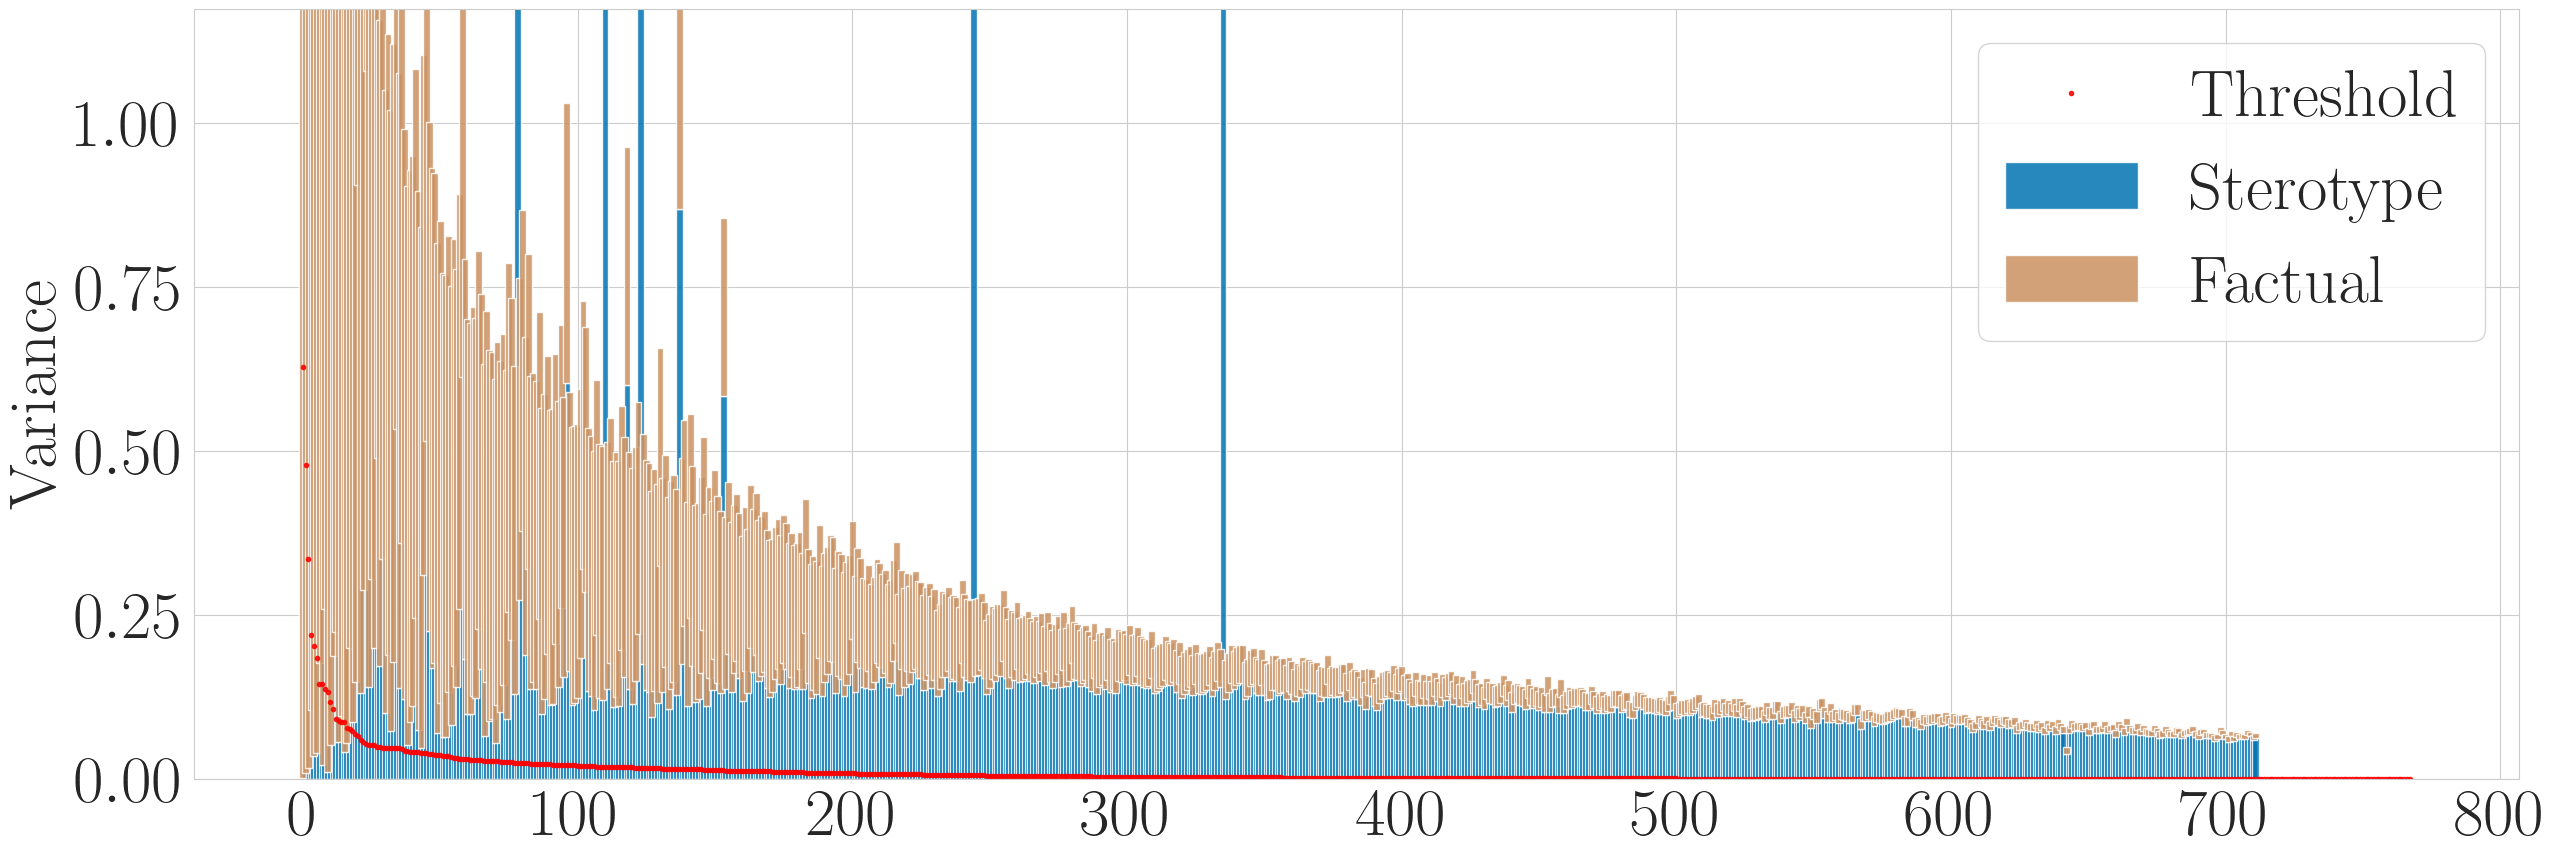

In [149]:
layer = 26
s = variance_analysis[layer]['s']
b_share = variance_analysis[layer]['b_share']
f_share = variance_analysis[layer]['f_share']

variance_share(s, b_share, f_share, number_of_eigenvalues=768, log_scale=False, threshold=0.05,
               layer=layer, model_name="llama2_13B")

In [112]:
count_bias_dimensions(s, b_share, f_share, threshold=0.05, tol=1e-3)

For threshold 0.05 and eigenvaluer tolerance 0.001
********************
Bias selected dimension share: 0.9831460674157303
Bias no factual dimensions: 700
Bias nonzero varaiance dimension count: 712
Factual nonzero varaiance dimension count: 712
Total nonzero varaiance dimension count: 712
Bias variance mitigated: 0.995808482170105
Factual variance mitigated: 0.6936568021774292


(700, 712, 0.9958085, 0.6936568)

# Analyzis across layers

In [150]:
layers = [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
var_res = pd.DataFrame(columns=['layers', 'mitigated dims', 'bias dims', 'bias var mitigated', 'factual var mitigated'])


For threshold 0.05 and eigenvaluer tolerance 0.001
********************
Bias selected dimension share: 0.9831460674157303
Bias no factual dimensions: 700
Bias nonzero varaiance dimension count: 712
Factual nonzero varaiance dimension count: 712
Total nonzero varaiance dimension count: 712
Bias variance mitigated: 0.995808482170105
Factual variance mitigated: 0.6936568021774292
For threshold 0.05 and eigenvaluer tolerance 0.001
********************
Bias selected dimension share: 0.9831460674157303
Bias no factual dimensions: 700
Bias nonzero varaiance dimension count: 712
Factual nonzero varaiance dimension count: 712
Total nonzero varaiance dimension count: 712
Bias variance mitigated: 0.995808482170105
Factual variance mitigated: 0.6936568021774292
For threshold 0.05 and eigenvaluer tolerance 0.001
********************
Bias selected dimension share: 0.9767441860465116
Bias no factual dimensions: 756
Bias nonzero varaiance dimension count: 774
Factual nonzero varaiance dimension count:

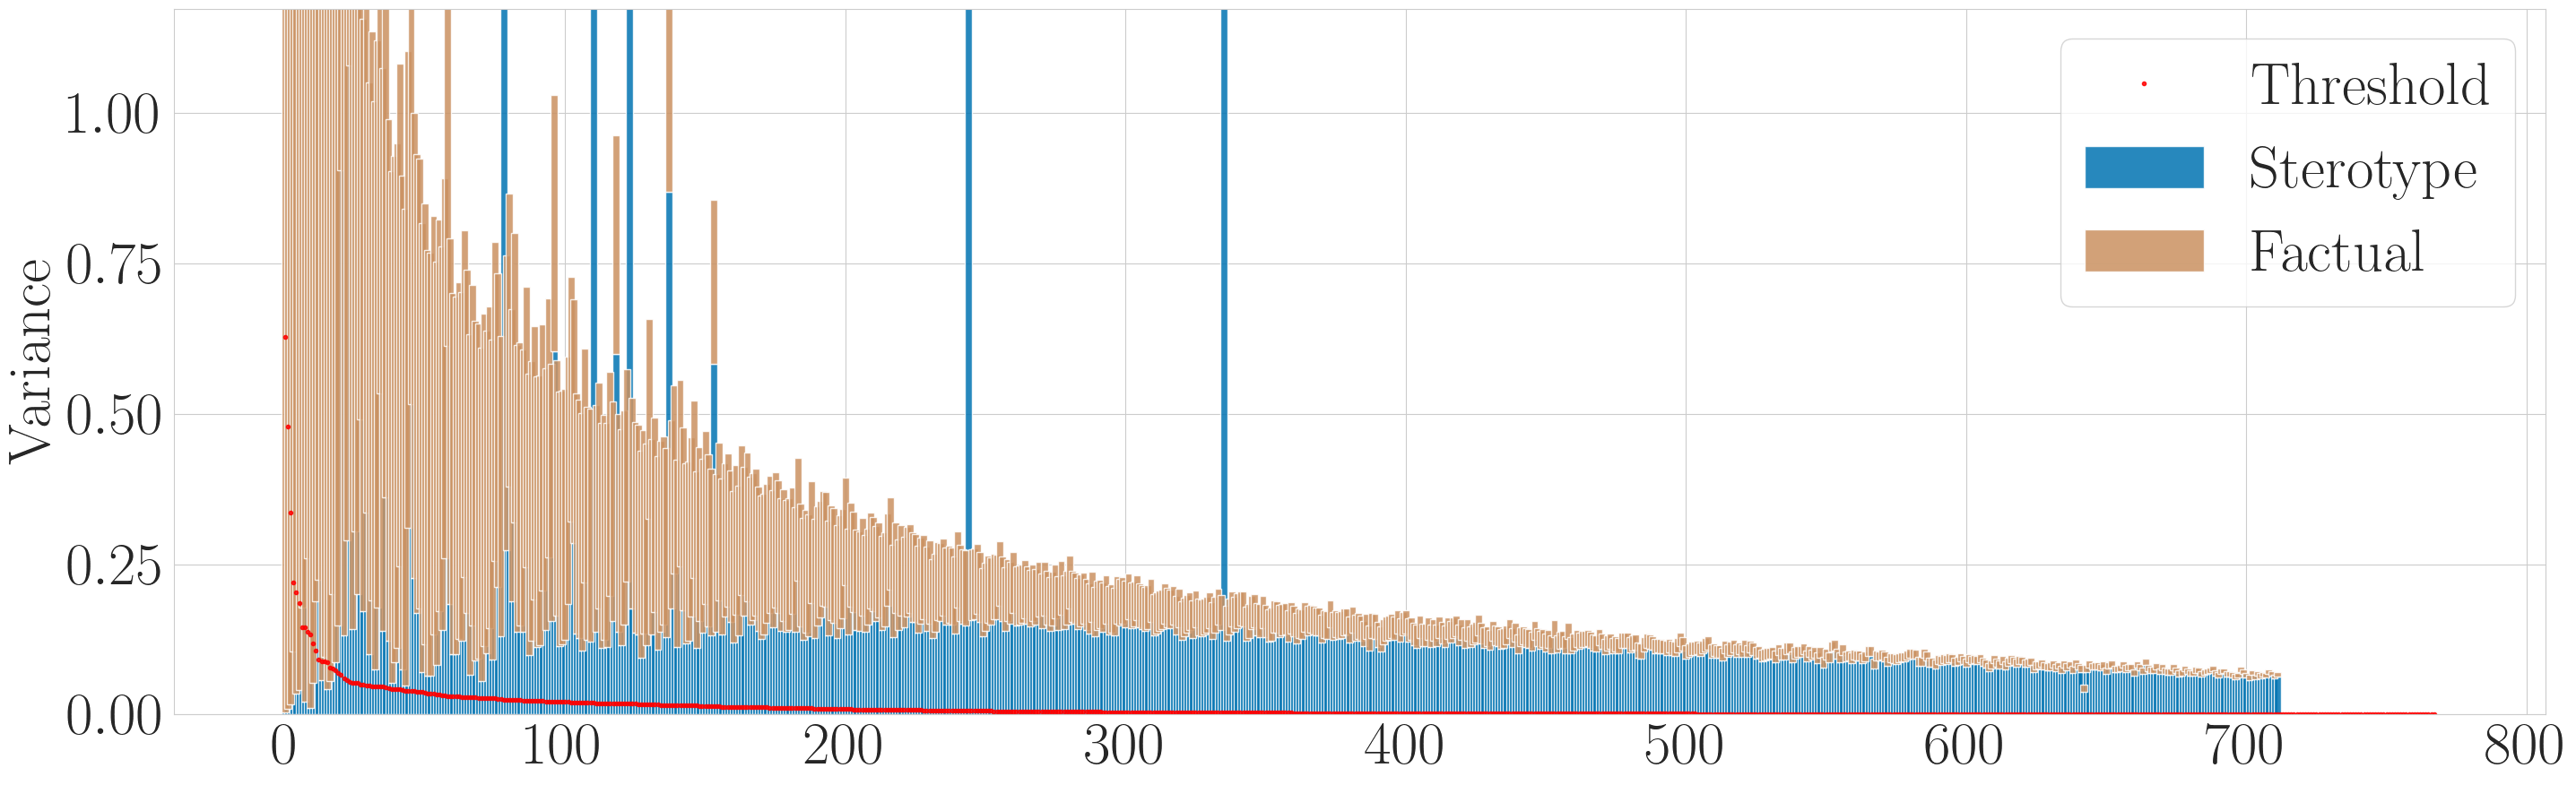

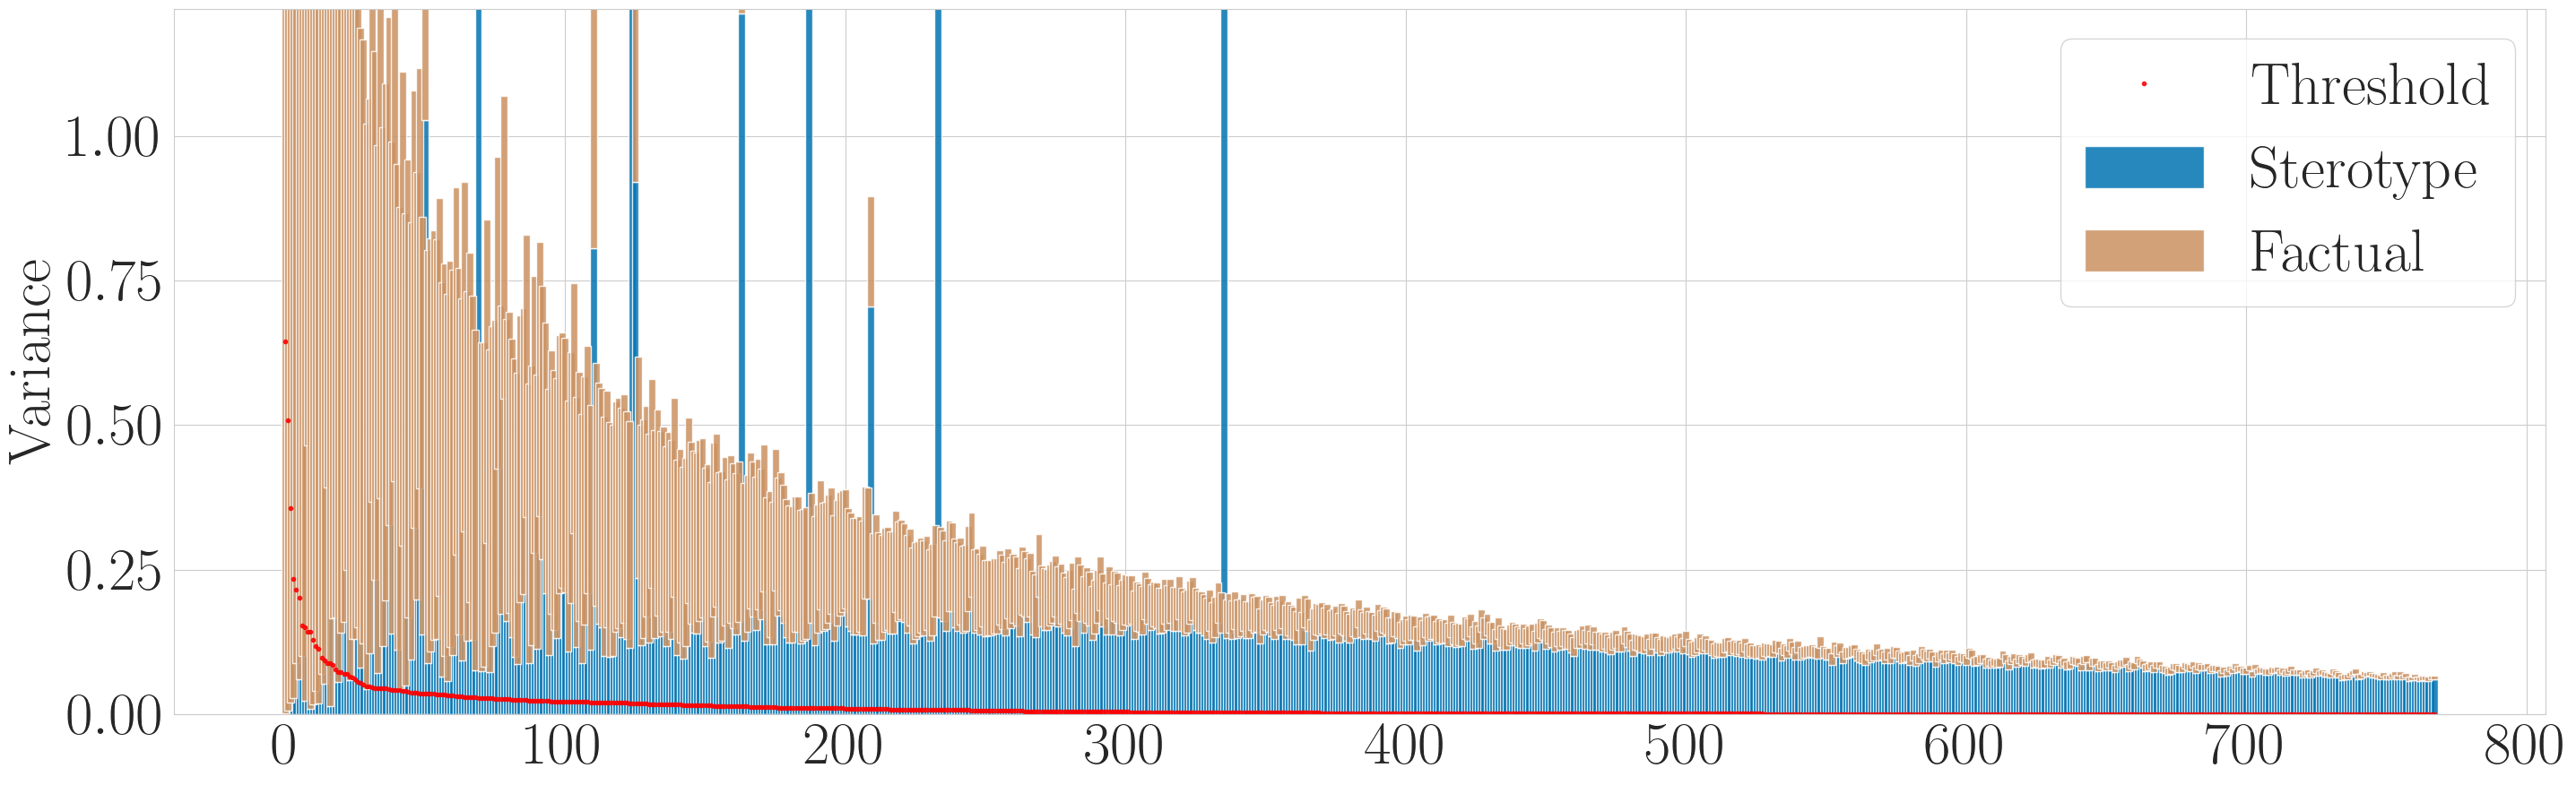

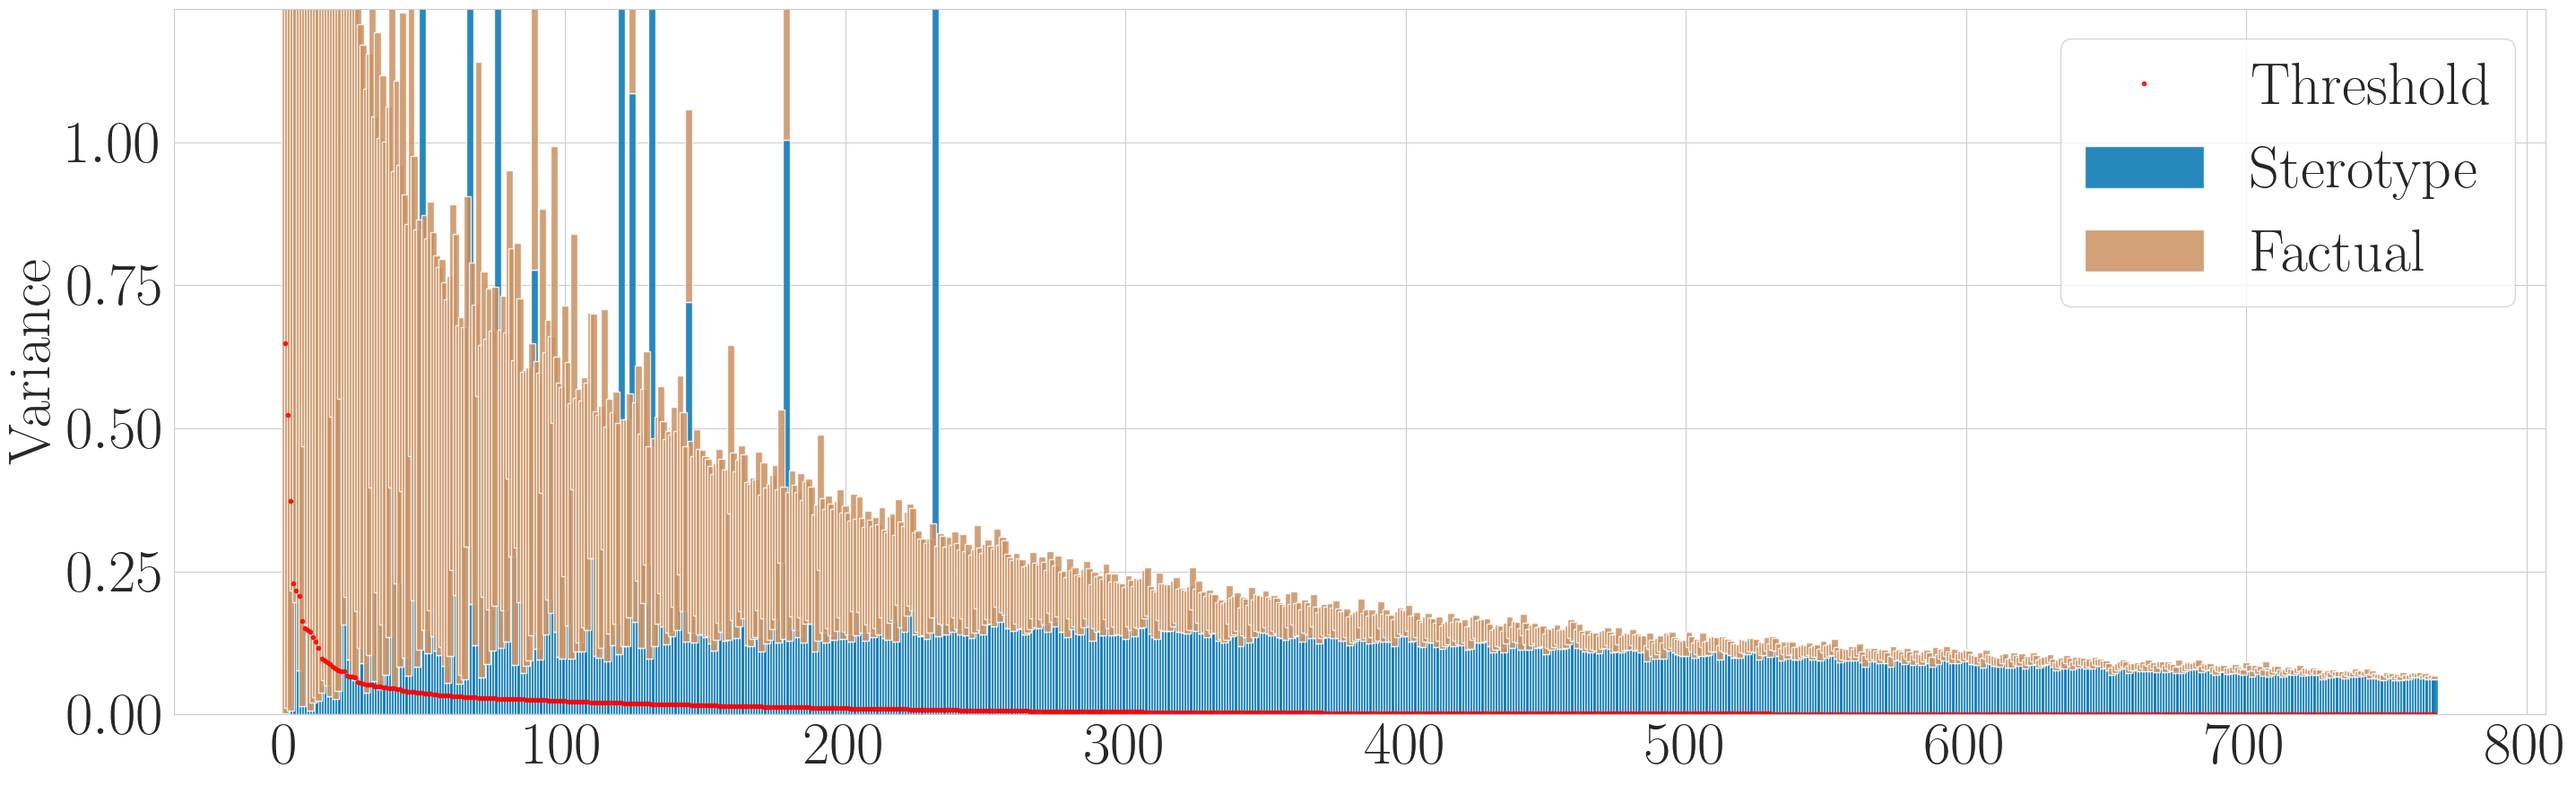

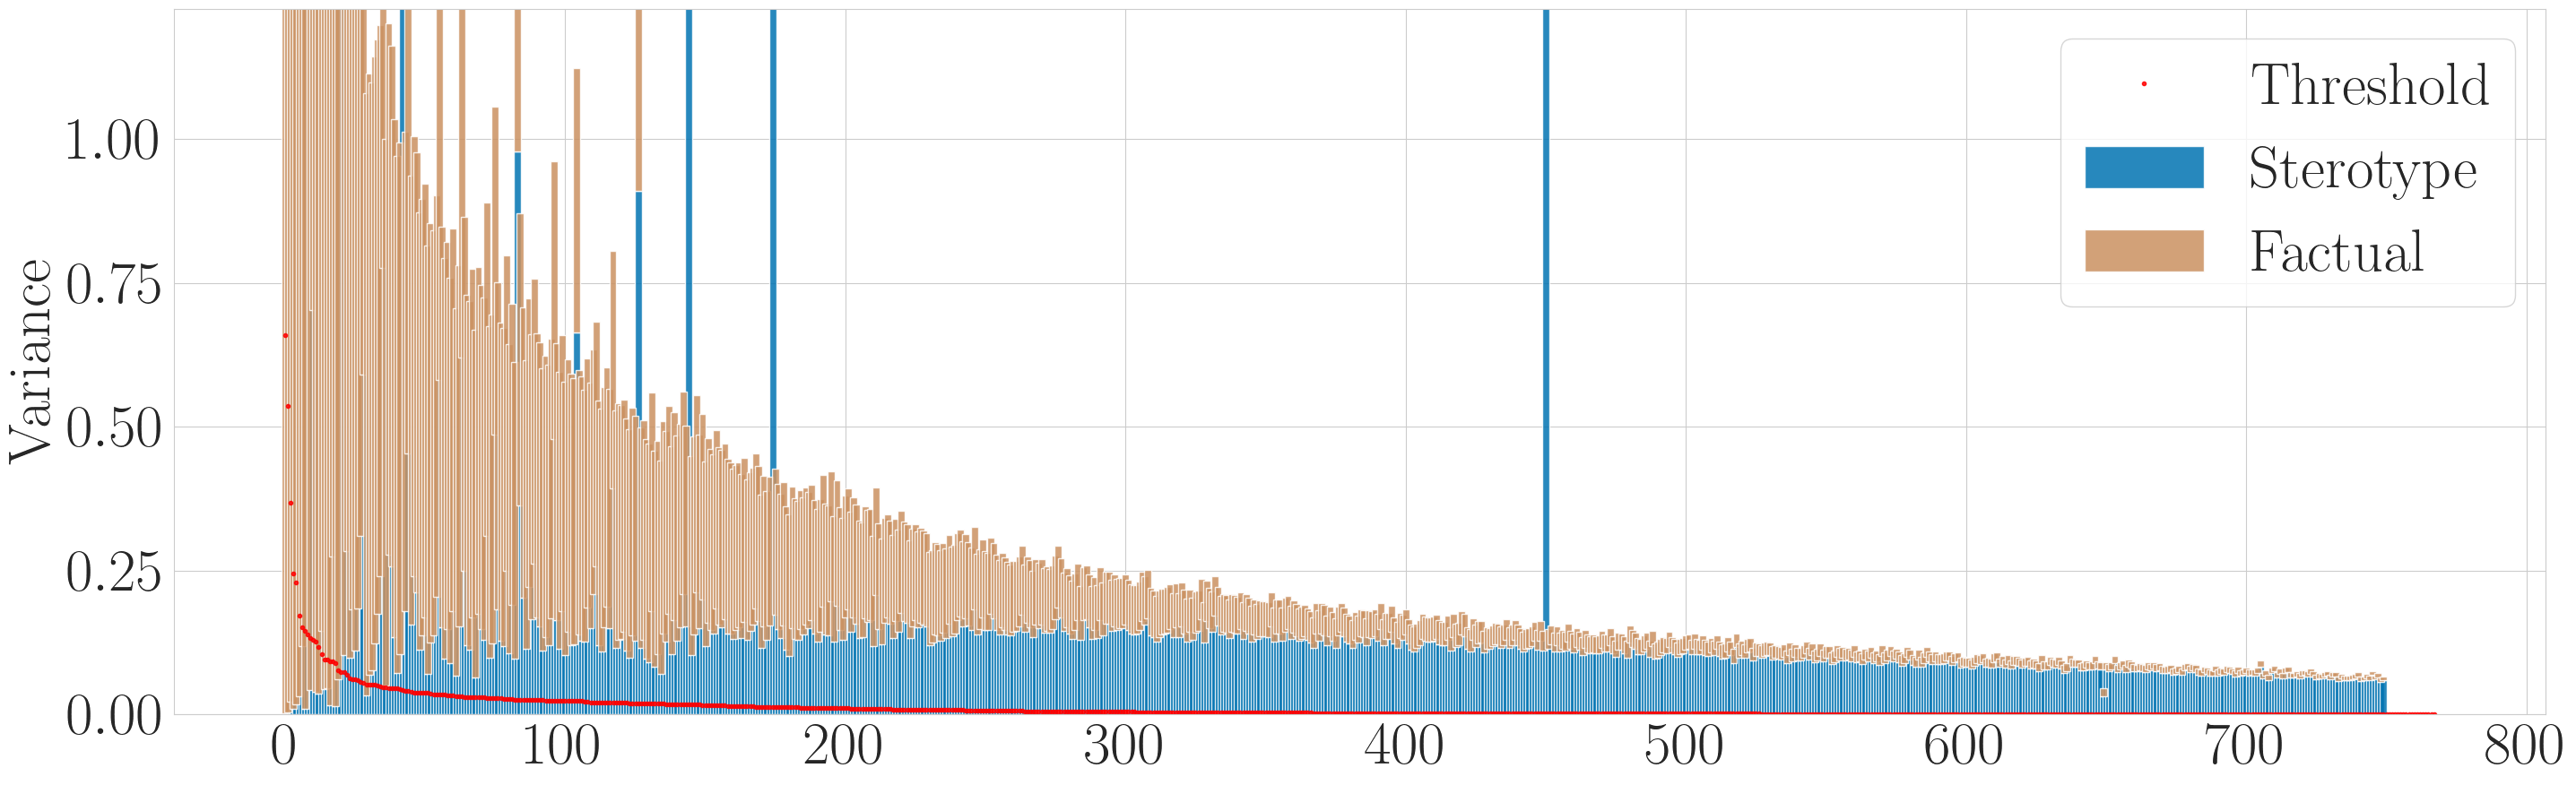

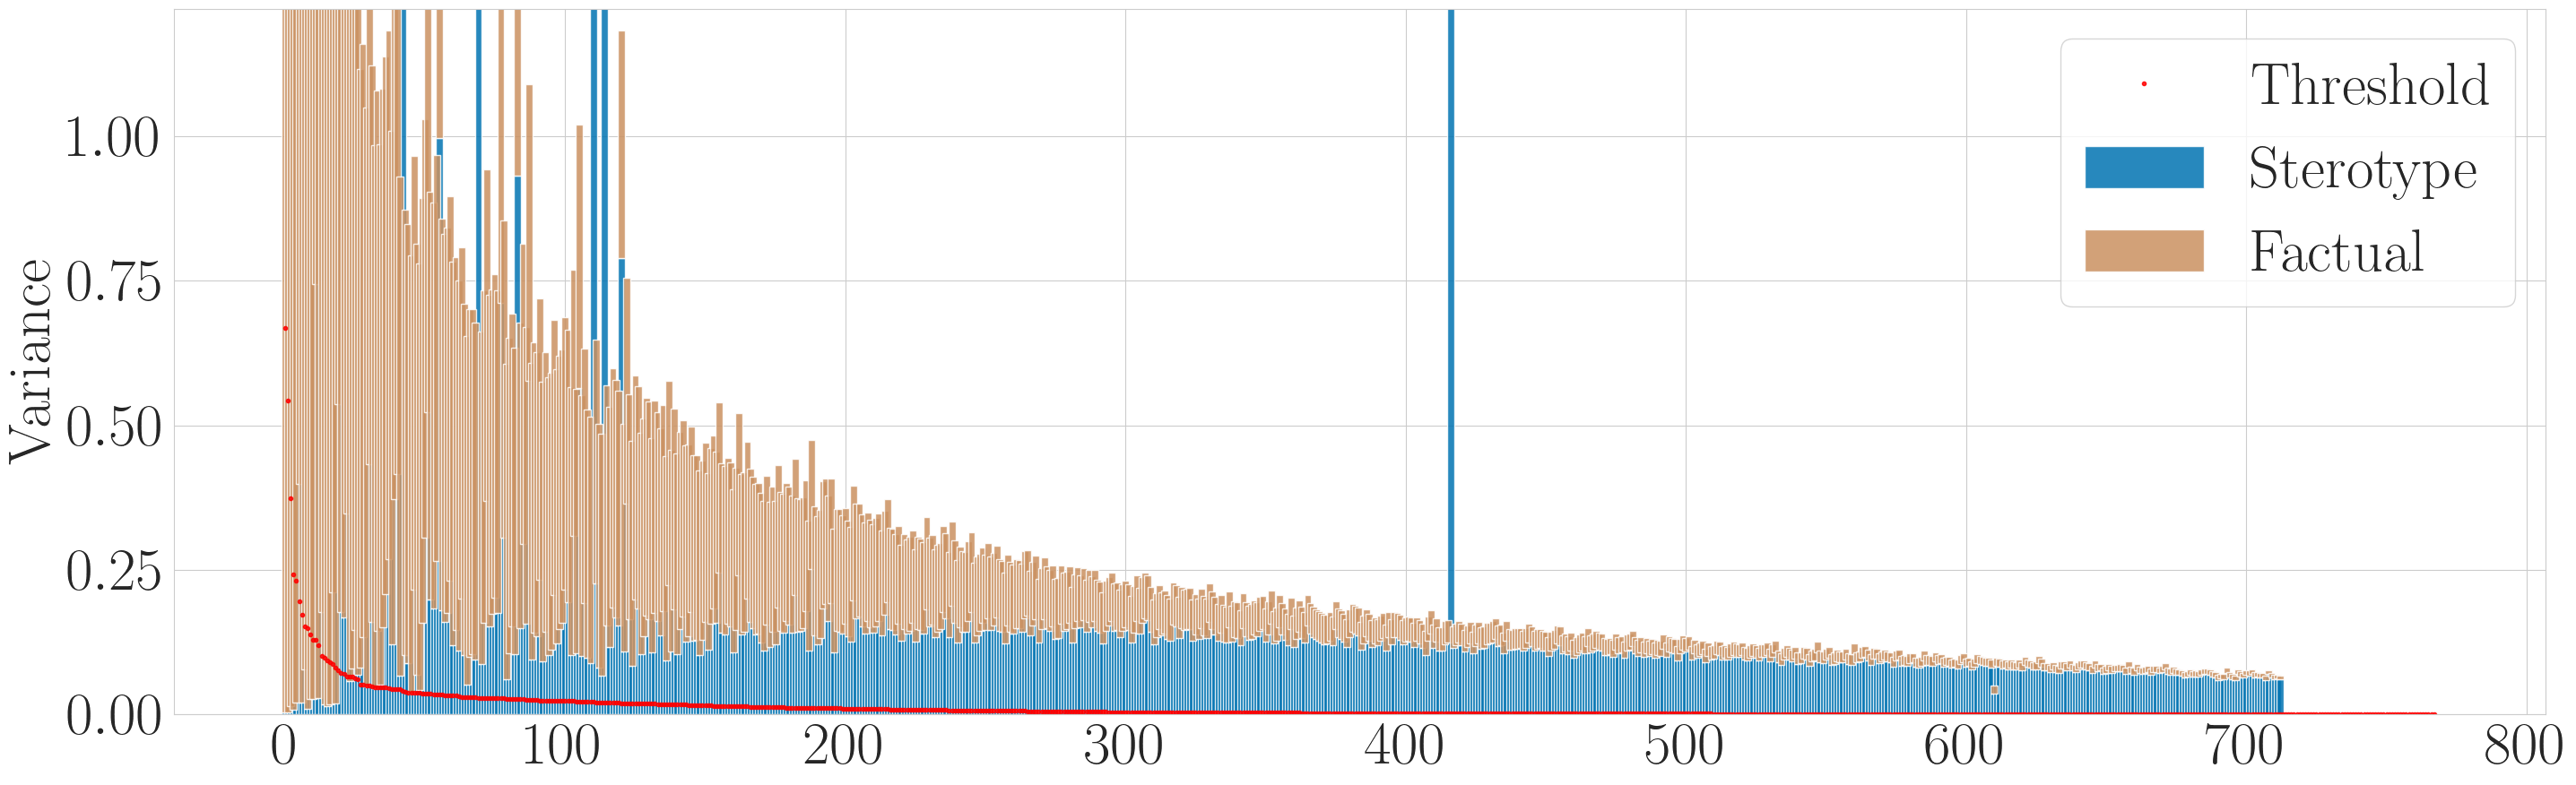

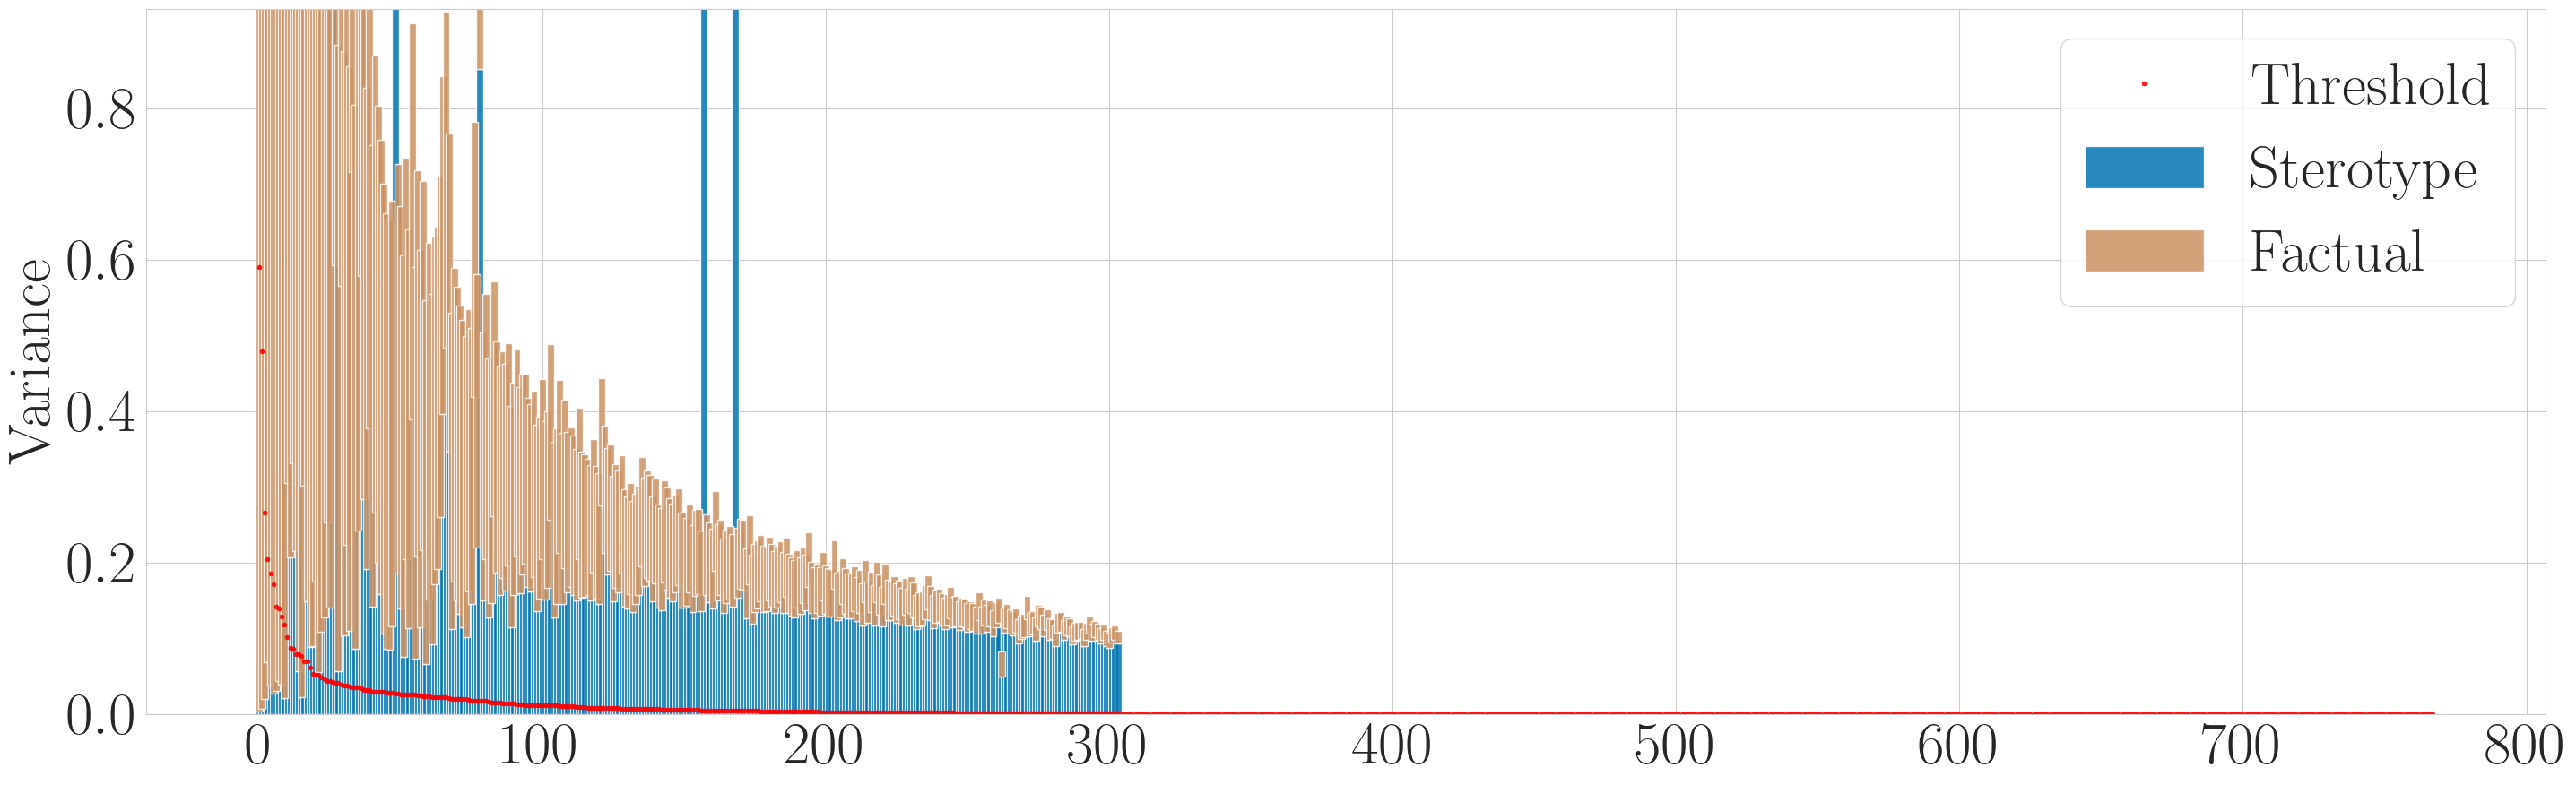

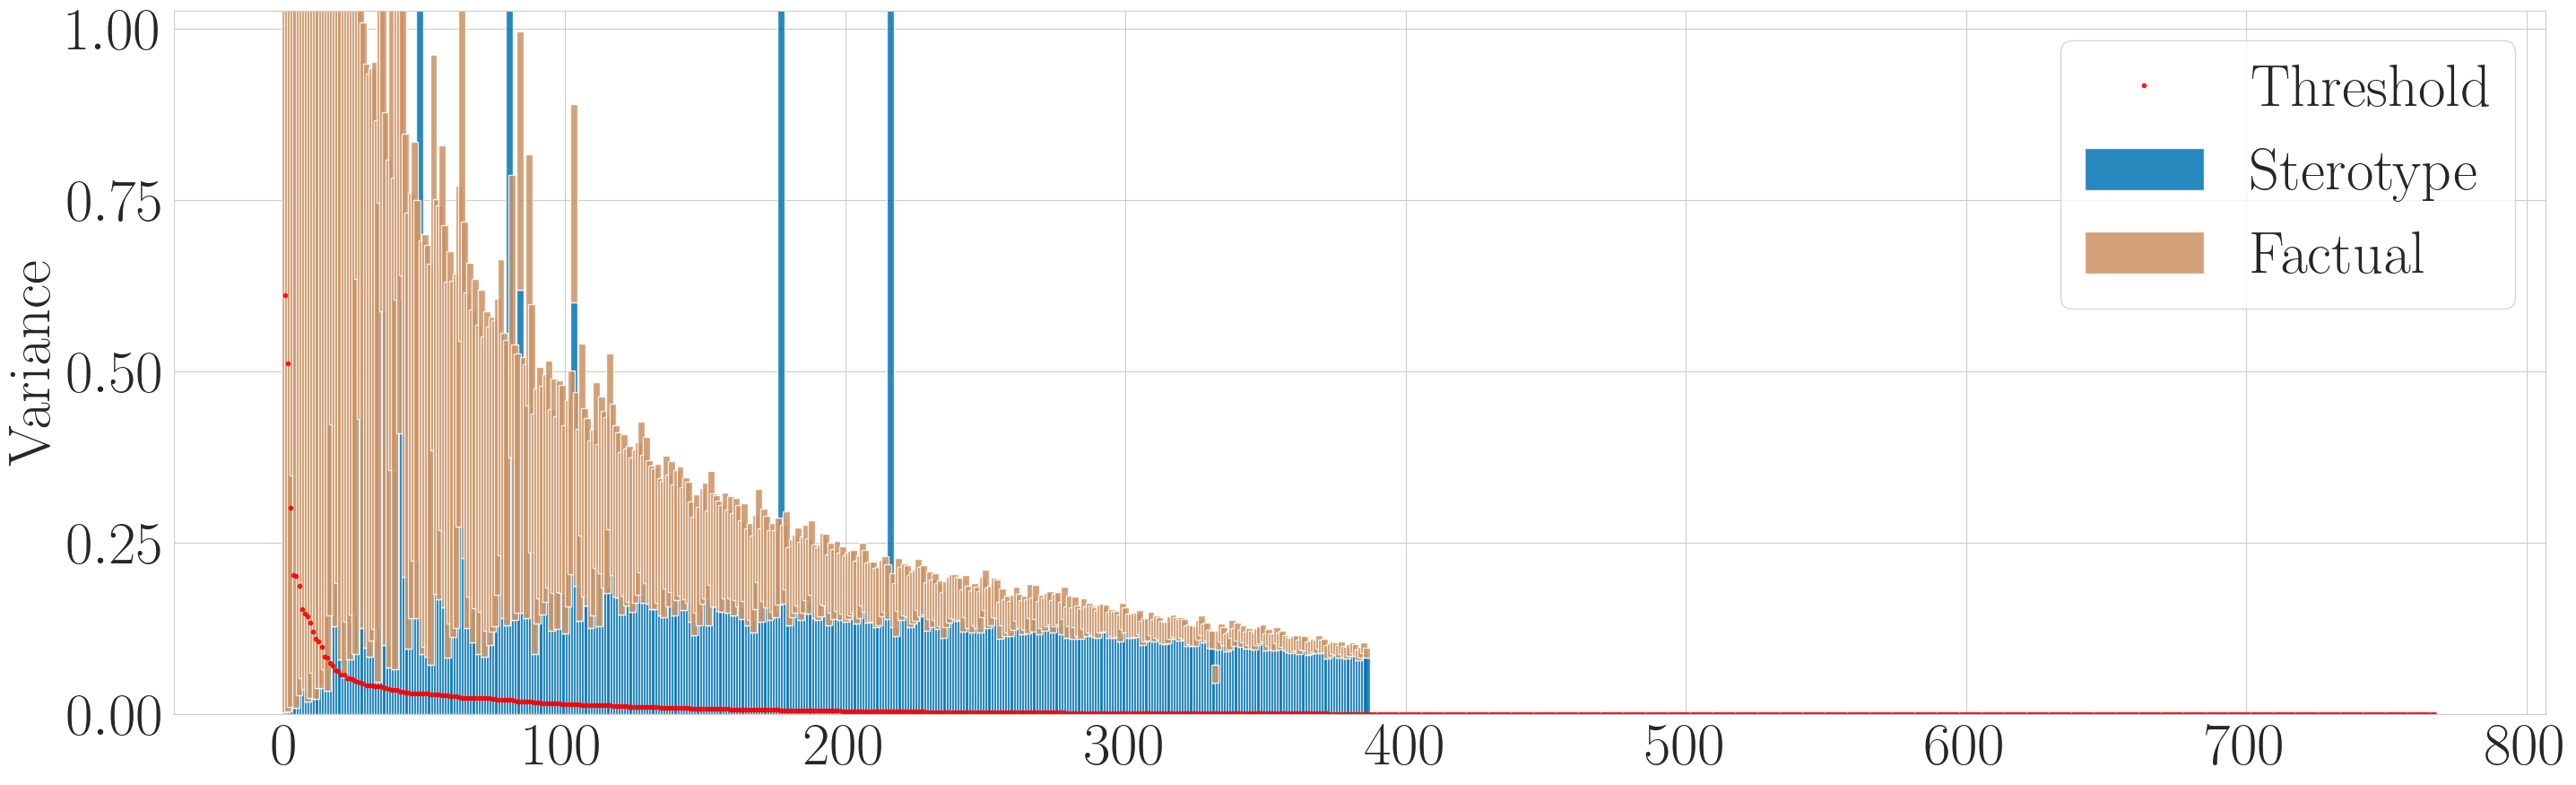

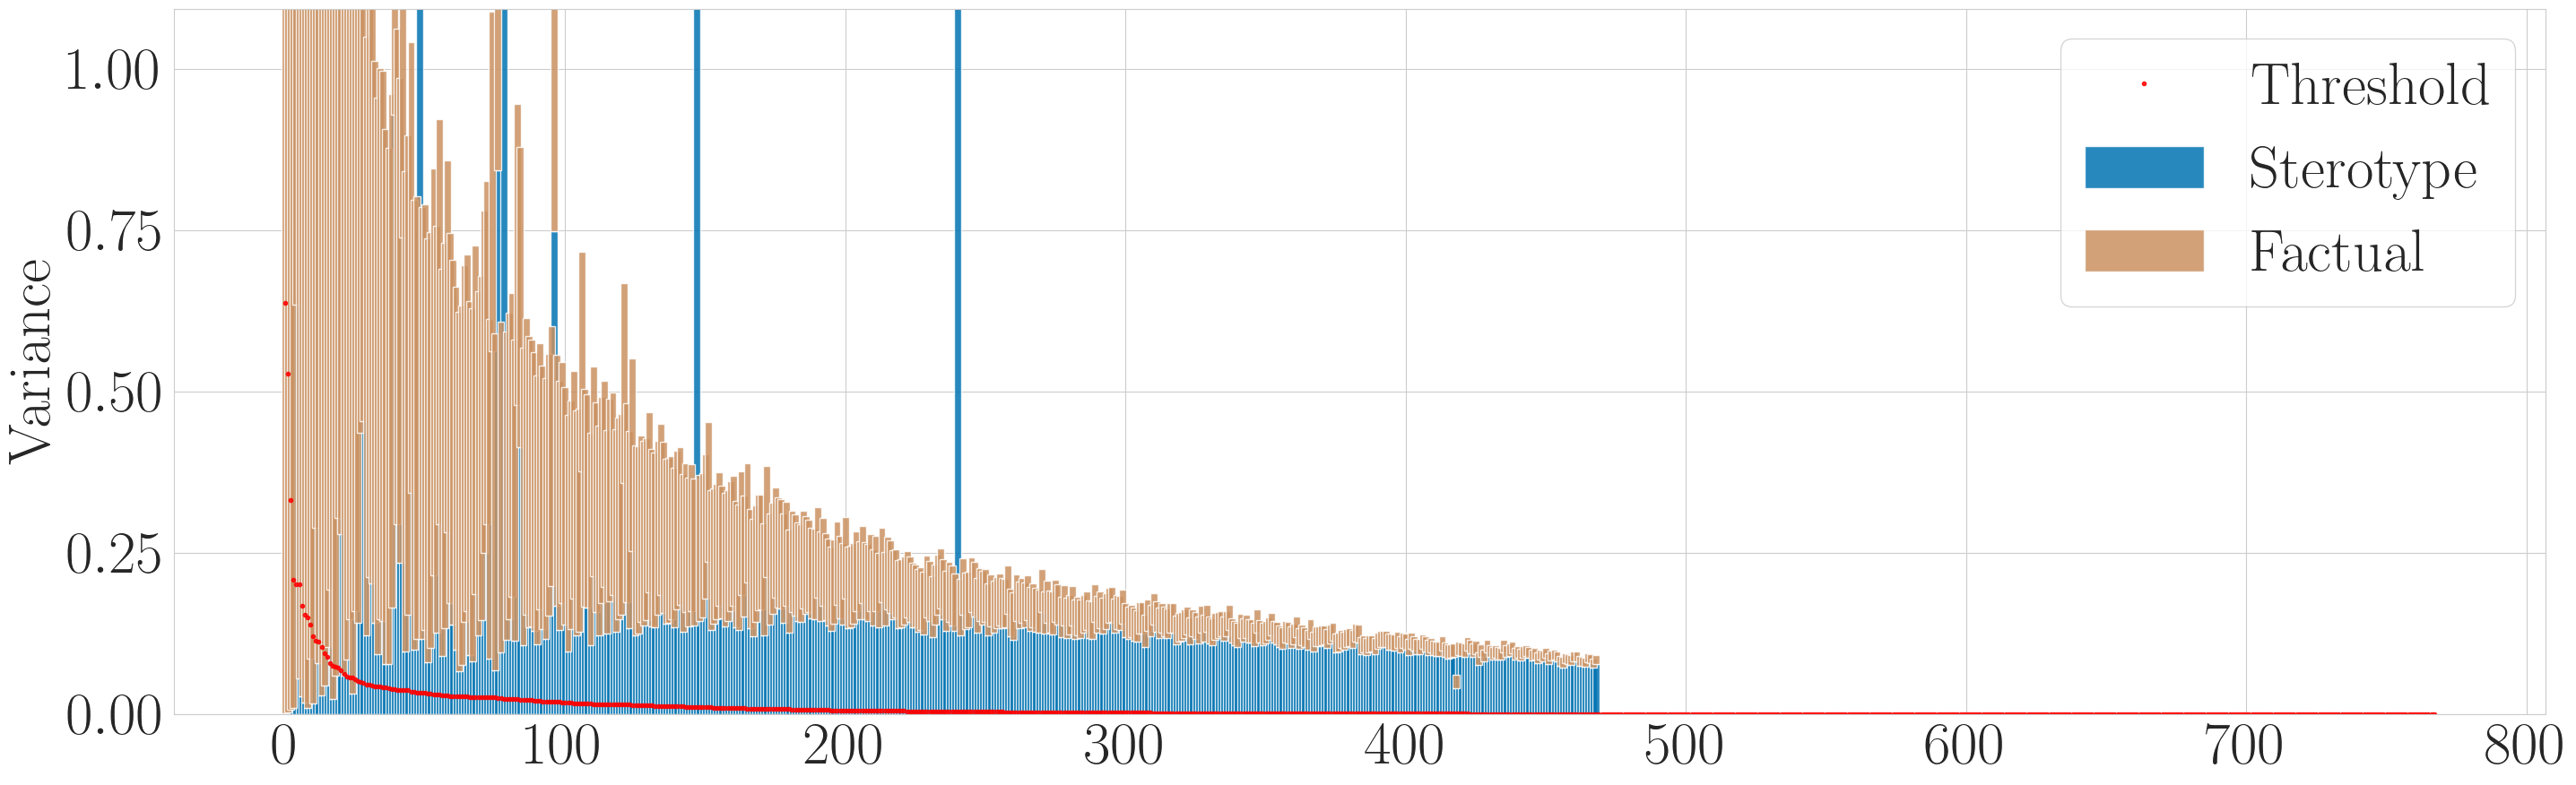

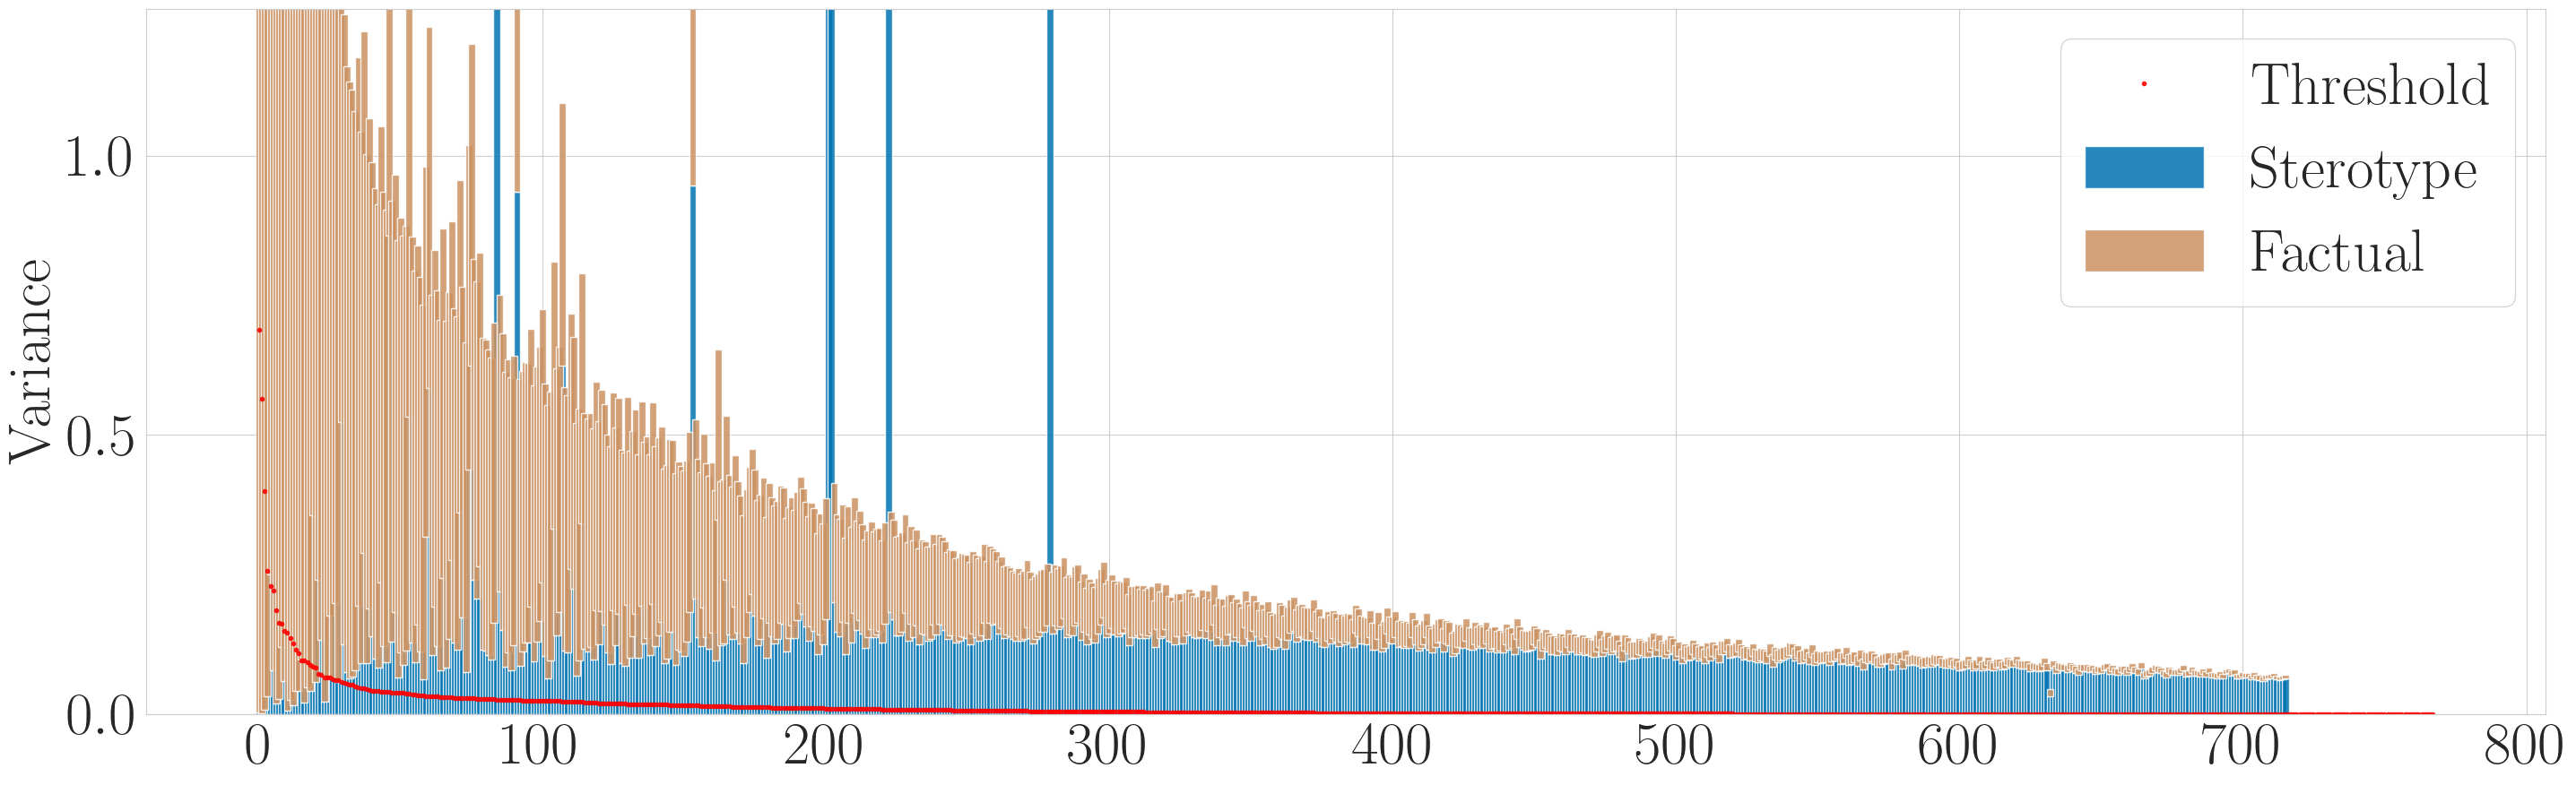

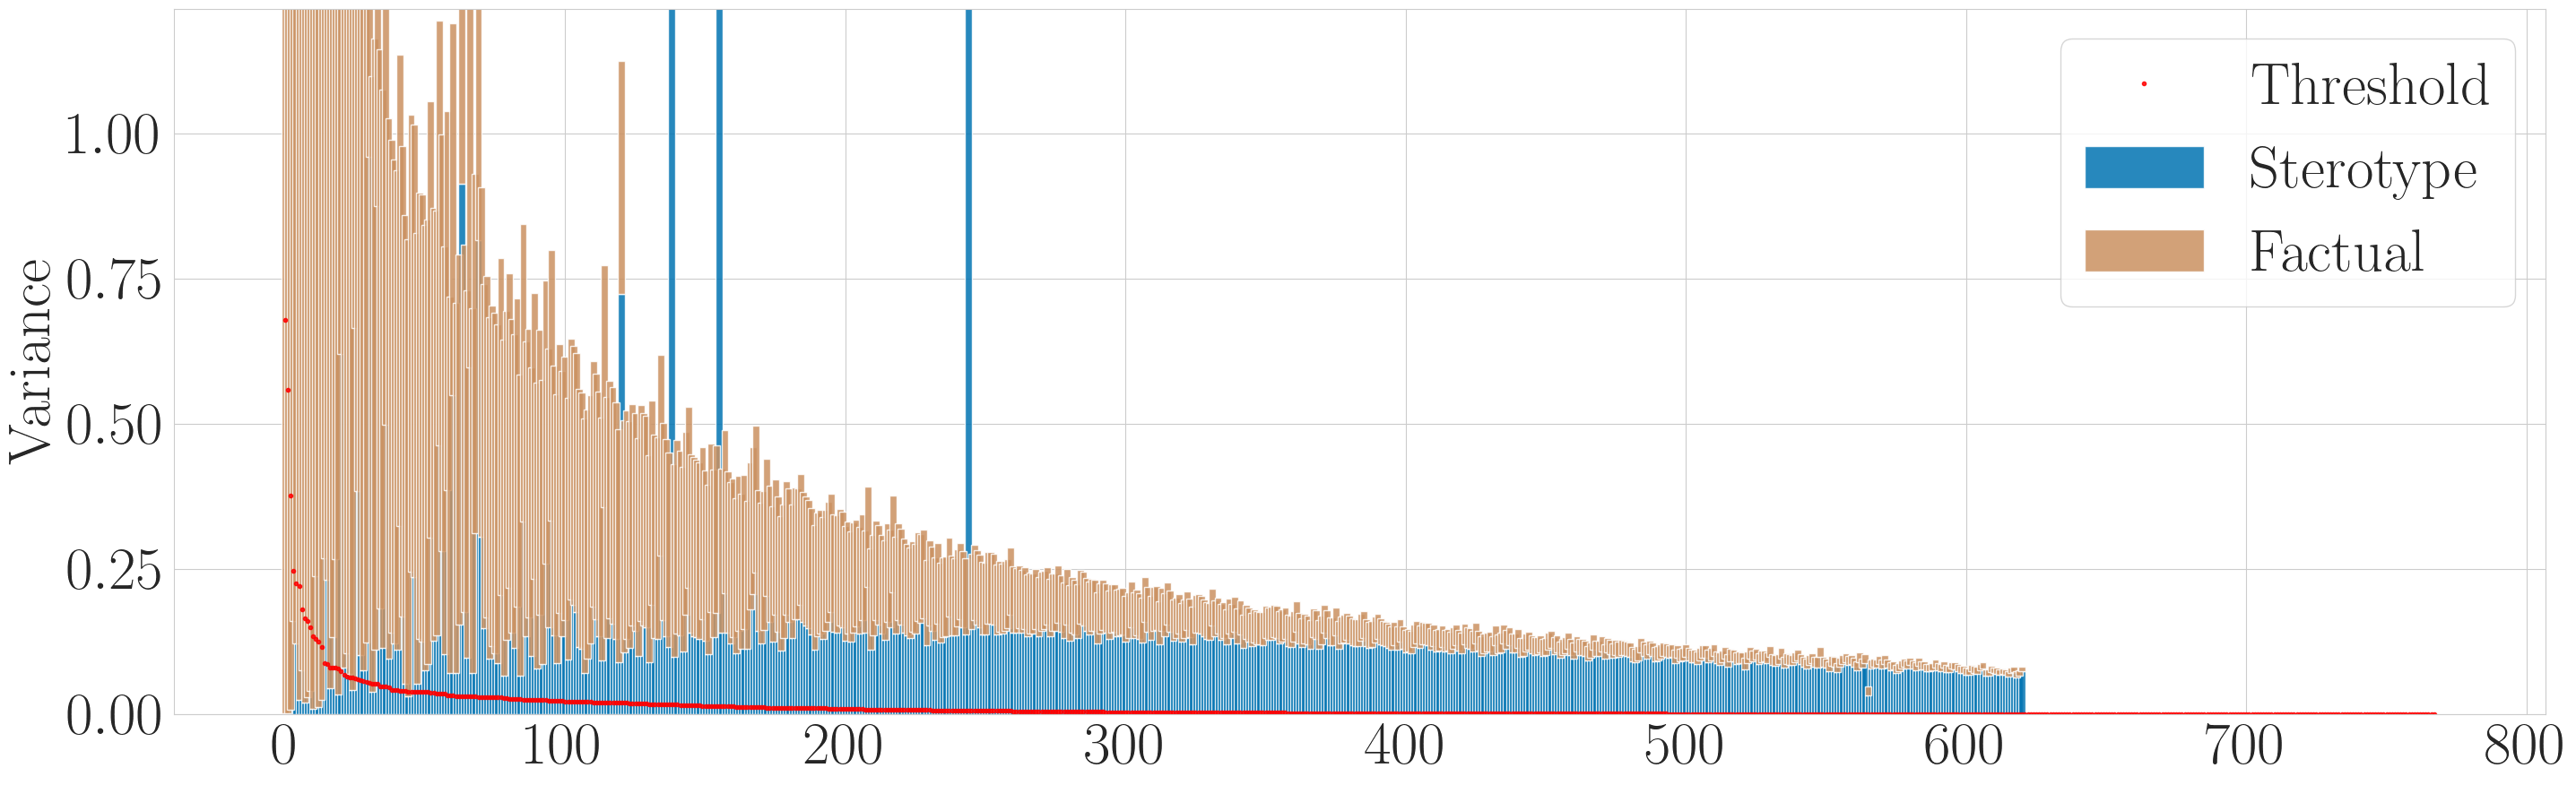

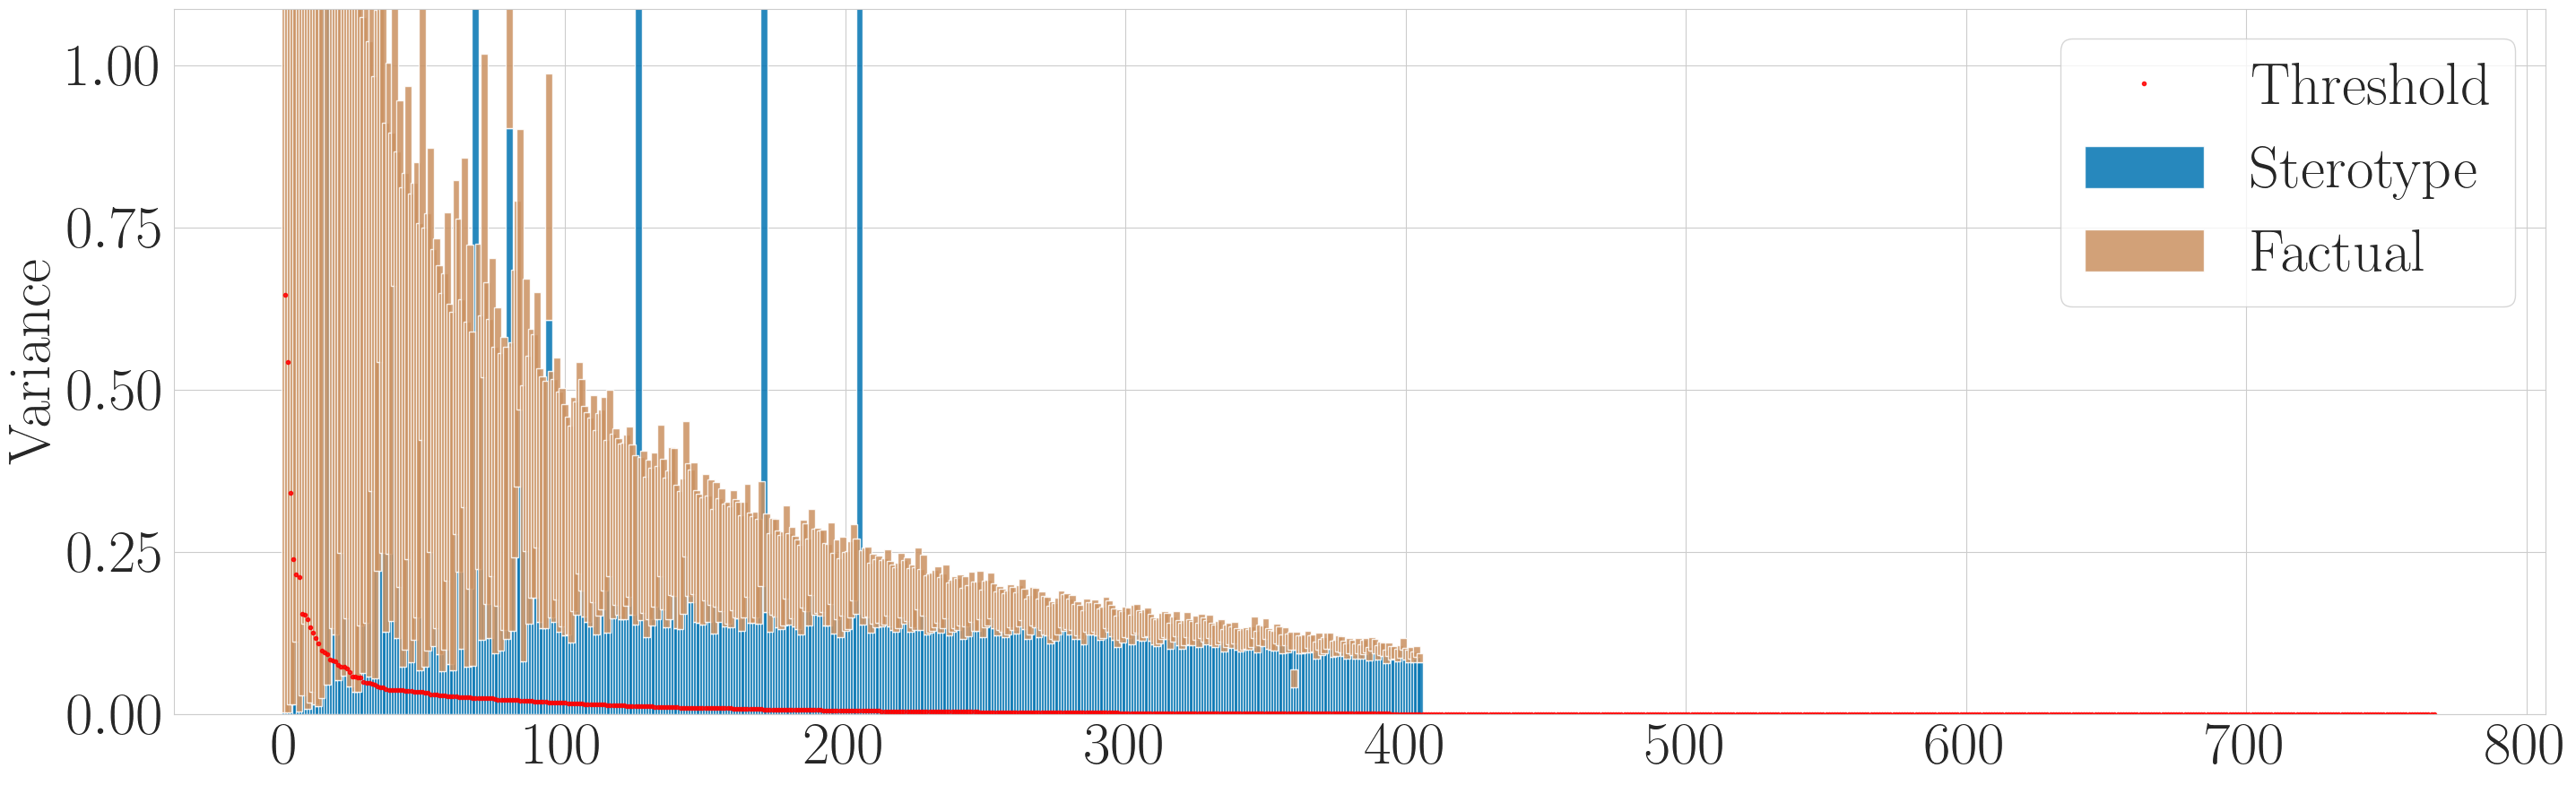

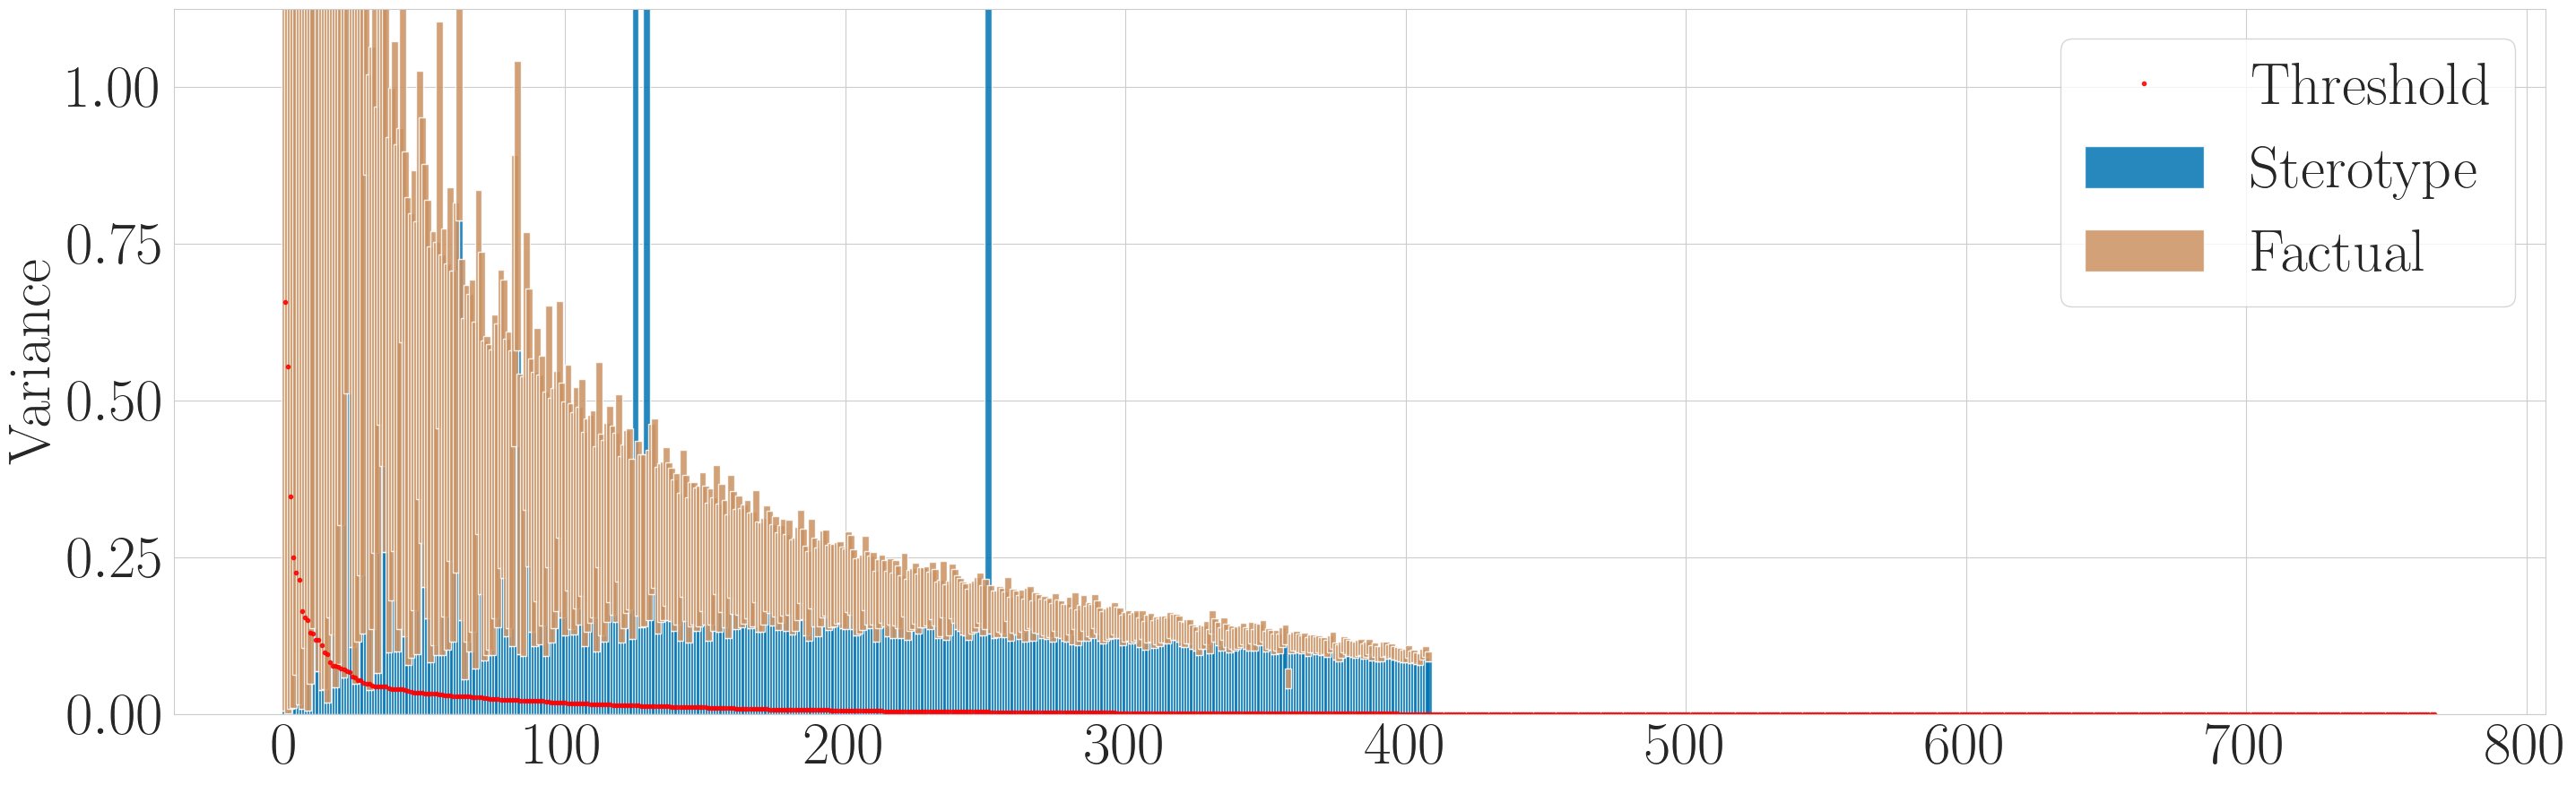

In [151]:
for layer in layers:
    s = variance_analysis[layer]['s']
    b_share = variance_analysis[layer]['b_share']
    f_share = variance_analysis[layer]['f_share']
    count_bias_dimensions(s, b_share, f_share, threshold=0.05, tol=1e-3)
    variance_share(s, b_share, f_share, number_of_eigenvalues=768, log_scale=False, threshold=0.05,
               layer=layer, save_dir=OUTPUT_DIR, model_name="llama2_13B")

    mitigated_dims, bias_dims, bias_var_mitigated, factual_var_mitigated = count_bias_dimensions(s, b_share, f_share, threshold=0.05, tol=1e-3)
    var_res.loc[len(var_res)] = {'layers': layer, 'mitigated dims': mitigated_dims, 'bias dims': bias_dims, 'bias var mitigated': bias_var_mitigated, 'factual var mitigated': factual_var_mitigated}


In [122]:
display(var_res)

,layers,mitigated dims,bias dims,bias var mitigated,factual var mitigated
0,26,700,712,0.995808,0.693657
1,27,756,774,0.993705,0.639593
2,28,760,782,0.990293,0.624120
3,29,733,750,0.995041,0.653617
4,30,694,713,0.995286,0.639961
5,31,292,304,0.993149,0.576253
6,32,371,387,0.992401,0.570471
7,33,452,469,0.992464,0.601466
8,34,695,716,0.992360,0.612606
9,35,603,621,0.992216,0.621845


In [123]:
var_res.to_csv(os.path.join(OUTPUT_DIR, '2dama_concept_erased_dimensions.csv'), index=False)